# **Lab 01 - Introduction to Python, Gymnasium and Formulating RL Problem**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Getting familiar with Gymnasium

In [11]:
# import Gymnasium library and alias as gym
import gymnasium as gym

In [12]:
total_reward = 0
truncated = False
done = False

In [13]:
# Create the MountainCar-v0 environment and reset to obtain the initial observation
### YOU NEED TO WRITE YOUR CODE BELOW ###
# HERE 
env =gym.make("MountainCar-v0", render_mode= "human")
observation, _ =env.reset(seed=2026)


In [14]:

while not done and not truncated:

    # Define action by sampling randomly from the environment action space
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    action =env.action_space.sample()

    # Execute the action
    pos = observation[0]
    v = observation[1]

    if v < 0:
        action = 0   # đẩy sang trái
    else:
        action = 2   # đẩy sang phải
    # HERE
    new_obs, reward, done, truncated, info = env.step(action)

    total_reward += reward
    observation = new_obs
    env.render()

print("Reward: {}".format(total_reward))
env.close()

Reward: -114.0


## Part 2: Custom Environment "VacuumCleaner"

In [8]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        self.action_space = gym.spaces.Discrete(4)

        # Observation space: position and dust grid
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(low=0, high=self.m-1, shape=(2,), dtype=int),
            'dust': gym.spaces.Box(low=0, high=1, shape=(self.m, self.n), dtype=int)
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.position = np.array([0,0], dtype=int)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.dust_grid = np.random.randint(2, size=(self.m, self.n))

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = self.position + np.array([-1,0])
        elif action == 1: # Down
            candidate = self.position + np.array([1,0])
        elif action == 2: # Left
            candidate = self.position + np.array([0,-1])
        elif action == 3: # Right
            candidate = self.position + np.array([0,1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        x, y = self.position
        if self.dust_grid[x, y] == 1:
            reward = 1.0
            self.dust_grid[x, y] = 0
        else:
            reward = -0.5

        self.total_reward += reward
        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [9]:
def robot_policy(option="random", env=None):
    # RANDOM POLICY
     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
    # ROUND ROBIN POLICY
     elif option == "round_robin":
          row, col = env.position
          # {0: up, 1: down, 2: left, 3: right}
          if row % 2 == 0: 
               if col < env.n - 1:
                    return 3 
               else:
                    return 1 
          else: 
               if col > 0:
                    return 2  
               else:
                    return 1 
     # PRIORITY POLICY
     elif option == "priority":
          x, y = env.position

          moves = [(-1,0),(1,0),(0,-1),(0,1)]
          turn_right = {0:3, 3:1, 1:2, 2:0}

          if not hasattr(env, "current_direct"):
               env.current_direct = 3

          for action in range(4):
               dx, dy = moves[action]
               nx, ny = x + dx, y + dy #nx = new x

               if 0 <= nx < env.m and 0 <= ny < env.n:
                    if (nx, ny) != env.obstacle and env.dust_grid[nx, ny] == 1:
                         env.current_direct = action
                         return action
                         
          for _ in range(4):
               dx, dy = moves[env.current_direct]
               nx, ny = x + dx, y + dy

               if 0 <= nx < env.m and 0 <= ny < env.n and (nx, ny) != env.obstacle:
                    return env.current_direct
               
               env.current_direct = turn_right[env.current_direct]


     return env.action_space.sample()

In [ ]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = robot_policy(option="round_robin", env=env) # Changed to "round_robin" for round-robin based policy
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

3. Chạy 100 episodes, tổng hợp reward và vẽ biểu đồ bằng thư viện Matplotlib.

     - Cần phải tải thư viện về: pip install matplotlib

Chạy từng policy

In [ ]:
import matplotlib.pyplot as plt
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))

    sum_reward = []
    for episode in range(100):
        obs, _ = env.reset()
        terminated = False
        truncated = False

        while not terminated and not truncated:
            action = robot_policy(option="round_robin", env=env) 
            obs, reward, terminated, truncated, info = env.step(action)
        
        sum_reward.append(env.total_reward)
        print(f"Episode {episode+1}: total reward = {env.total_reward}")
plt.plot(sum_reward)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Performance of Round-Robin Policy")
plt.legend()
plt.grid(True)
plt.show()



Chạy tất cả policy

In [ ]:
import matplotlib.pyplot as plt

if __name__ == "__main__":
    policies = ["random", "round_robin", "priority"]
    rewards = {}

    # run experiments
    for policy in policies:
        rewards[policy] = []

        for episode in range(100):
            obs, _ = env.reset()
            terminated = False
            truncated = False

            while not terminated and not truncated:
                action = robot_policy(option=policy, env=env)
                obs, reward, terminated, truncated, info = env.step(action)
            rewards[policy].append(env.total_reward)
            print(f"Policy: {policy} | Episode {episode+1} | Reward: {env.total_reward}")

    # plot results
    plt.figure(figsize=(8,5))
    for policy in policies:
        plt.plot(rewards[policy], label=policy)

    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Policy Performance Comparison")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
def save():
    pass

Evaluation and Analysis

## Part 3: Load Balancing Problem

In [10]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque
import gymnasium as gym

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if (self.current_task != None):
                  self.remaining_time -= 1
                  if self.remaining_time <= 0:
                        completed_task = self.current_task
                        self.current_task = None
            
            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if (self.current_task == None and len(self.queue) > 0):
                  self.current_task = self.queue.popleft()
                  self.remaining_time = self.current_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if(self.current_task == None):
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True
            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            elif len(self.queue) < self.queue_capacity:
                  self.queue.append(task)
                  return True
            else:
            # Queue full -> task dropped
                  return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [11]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(n_servers) #Choose 1 among n_servers

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(tuple(
                         gym.spaces.Dict({
                               "remaining_time": gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=np.float32),
                               "queue_length": gym.spaces.Discrete(queue_capacity + 1),
                         })
                         for _ in range(n_servers)
                  )),
                  "time": gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=np.float32),
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(task_id=self.next_task_id, processing_time=self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()

            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  completed_task = server.run_one_step()
                  if completed_task is not None:
                        self.tasks_completed.add(completed_task.task_id)
                        reward += 2.0

            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            selected_server = self.servers[action]
            accepted = selected_server.add_task(new_task)
            if accepted:
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0

            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * server.queue_length()

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = dropped / total_created if total_created > 0 else 0
            completion_rate = completed / total_created if total_created > 0 else 0

            return {
                  "time": self.time,
                  "total_created": total_created,
                  "accepted": accepted,
                  "dropped": dropped,
                  "completed": completed,
                  "drop_rate": drop_rate,
                  "completion_rate": completion_rate,
                  "total_reward": self.total_reward,
            }

SyntaxError: invalid syntax (1801122101.py, line 44)

In [12]:
def load_balancing_policy(option="random", env=None, epsilon=0.2):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()

      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE

      elif option == "round_robin":
            if not hasattr(env, '_rr_counter'):
                  env._rr_counter = 0
            action = env._rr_counter % env.n_servers
            env._rr_counter += 1
            return action

      elif option == "greedy":
            loads = []
            for server in env.servers:
                  load = server.remaining_time + server.queue_length()
                  loads.append(load)
            return int(np.argmin(loads))

      elif option == "epsilon_greedy":
            if random.random() < epsilon:
                  return env.action_space.sample()
            else:
                  loads = []
                  for server in env.servers:
                        load = server.remaining_time + server.queue_length()
                        loads.append(load)
                  return int(np.argmin(loads))

      raise ValueError(f"Unsupported policy option: {option}")

In [13]:
import csv

def save_metrics(metrics_list, filename="metrics.csv"):
      """
      Save a list of per-step metric dicts to a CSV file.

      Args:
            metrics_list: list of dicts, each dict is the info returned by env.step() at one step
            filename: output CSV file path
      """
      if not metrics_list:
            print("No metrics to save.")
            return

      # Use the keys of the first dict as CSV column headers
      fieldnames = list(metrics_list[0].keys())

      with open(filename, mode="w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            for row in metrics_list:
                  writer.writerow(row)

      print(f"Metrics saved to {filename} ({len(metrics_list)} rows)")

In [ ]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Collect metrics at each step for later CSV export
      all_metrics = []

      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="random", env=env)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            step_metrics = {"step": step + 1, "action": action, "reward": round(reward, 2)}
            step_metrics.update(info)
            all_metrics.append(step_metrics)
            print(f"Step {step+1}: action={action}, reward={reward:.2f}, info={info}")

      # Save all metrics to CSV
      save_metrics(all_metrics, filename="metrics.csv")

      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      print("\n=== Summary ===")
      print(f"Total reward: {env.total_reward:.2f}")
      print(f"Tasks created: {len(env.tasks_created)}")
      print(f"Tasks completed: {len(env.tasks_completed)}")
      print(f"Tasks dropped: {len(env.tasks_dropped)}")
      print(f"Drop rate: {info['drop_rate']:.2%}")
      print(f"Completion rate: {info['completion_rate']:.2%}")

Evaluation and Analysis

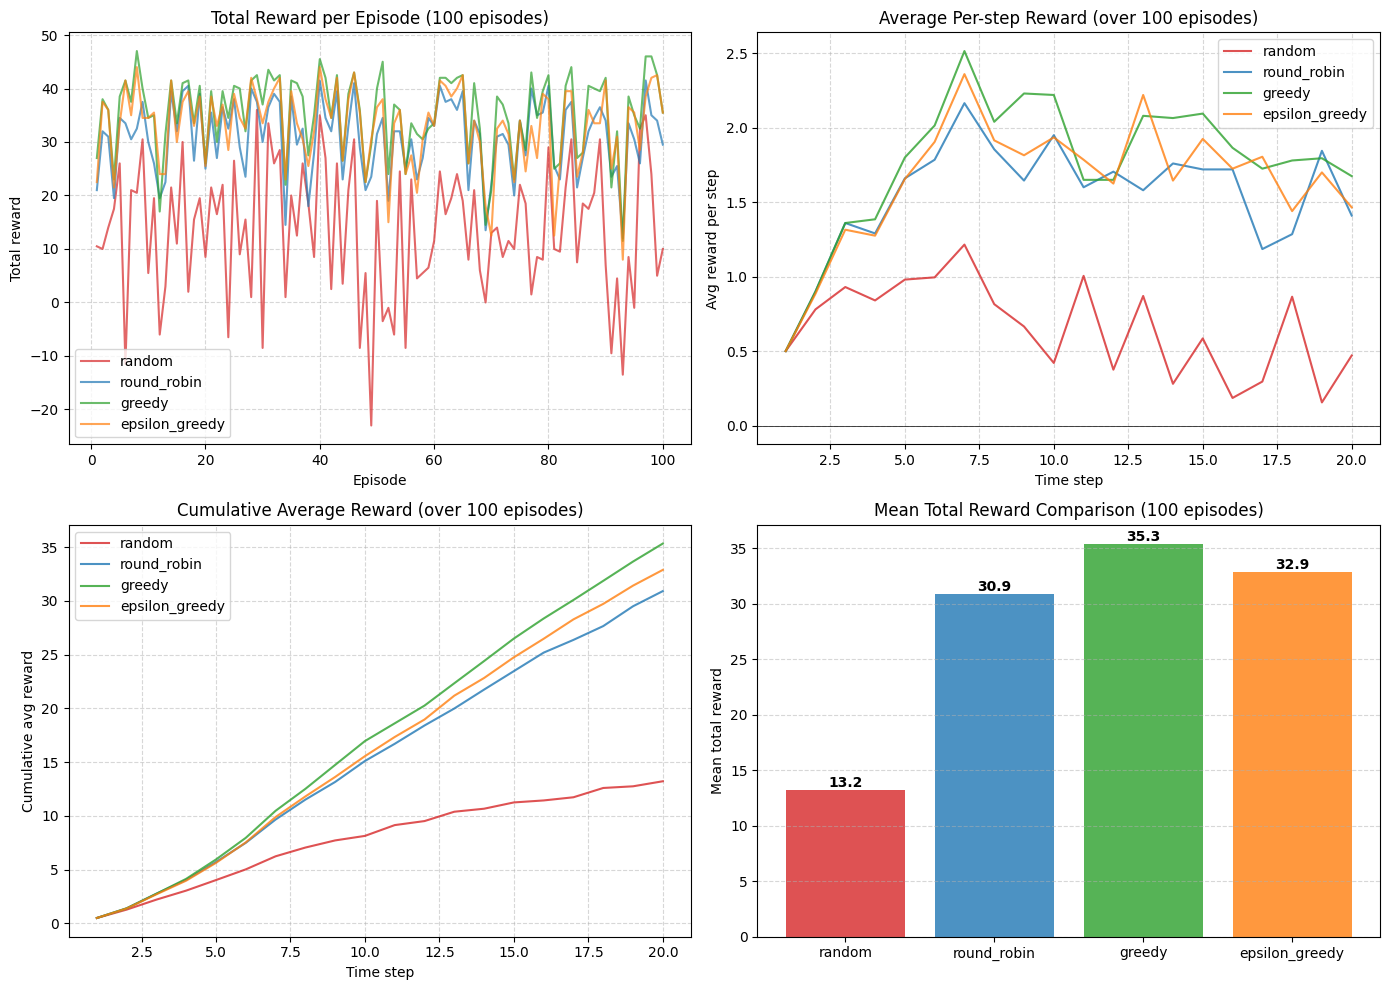

In [15]:
import sys
import subprocess
import numpy as np

try:
      import matplotlib.pyplot as plt
except ModuleNotFoundError:
      subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
      import matplotlib.pyplot as plt

def run_and_collect(policy_name, n_steps=20, n_servers=3, queue_capacity=2, seed=42, epsilon=0.2):
      """
      Run ONE episode of the LoadBalancing simulation with a given policy.

      Returns:
            steps: list of step indices [1, 2, ..., n_steps]
            per_step_rewards: reward received at each step
            cumulative_rewards: cumulative (total) reward up to each step
      """
      env = LoadBalancingEnv(n_servers=n_servers, queue_capacity=queue_capacity, seed=seed)
      env.reset()

      per_step_rewards = []
      cumulative_rewards = []
      cumulative = 0.0

      for step in range(n_steps):
            action = load_balancing_policy(option=policy_name, env=env, epsilon=epsilon)
            obs, reward, terminated, truncated, info = env.step(action)
            cumulative += reward
            per_step_rewards.append(reward)
            cumulative_rewards.append(cumulative)

      steps = list(range(1, n_steps + 1))
      return steps, per_step_rewards, cumulative_rewards


def run_multiple_episodes(policy_name, n_episodes=100, n_steps=20, n_servers=3, queue_capacity=2, epsilon=0.2):
      """
      Run multiple episodes and collect the total reward of each episode.

      Args:
            policy_name: policy to use
            n_episodes: number of episodes to run
            n_steps: steps per episode
      Returns:
            episode_rewards: list of total reward per episode (length = n_episodes)
            avg_per_step_rewards: average reward at each step across all episodes (length = n_steps)
      """
      episode_rewards = []
      all_per_step = np.zeros(n_steps)

      for ep in range(n_episodes):
            env = LoadBalancingEnv(n_servers=n_servers, queue_capacity=queue_capacity, seed=ep)
            env.reset()

            for step in range(n_steps):
                  action = load_balancing_policy(option=policy_name, env=env, epsilon=epsilon)
                  obs, reward, terminated, truncated, info = env.step(action)
                  all_per_step[step] += reward

            episode_rewards.append(env.total_reward)

      avg_per_step = all_per_step / n_episodes
      return episode_rewards, avg_per_step


def plot_rewards_100_episodes(n_episodes=100, n_steps=20):
      """
      Run all 4 policies over 100 episodes and plot:
        1) Total reward per episode (top-left)
        2) Average per-step reward across episodes (top-right)
        3) Cumulative average reward over time (bottom-left)
        4) Summary bar chart comparing mean total reward (bottom-right)
      """
      policies = ["random", "round_robin", "greedy", "epsilon_greedy"]
      colors = ["tab:red", "tab:blue", "tab:green", "tab:orange"]

      fig, axes = plt.subplots(2, 2, figsize=(14, 10))

      summary_means = []
      summary_labels = []

      for policy, color in zip(policies, colors):
            ep_rewards, avg_step = run_multiple_episodes(policy, n_episodes=n_episodes, n_steps=n_steps)
            episodes = list(range(1, n_episodes + 1))
            steps = list(range(1, n_steps + 1))
            cumulative_avg = np.cumsum(avg_step)

            # 1) Total reward per episode
            axes[0, 0].plot(episodes, ep_rewards, label=policy, color=color, alpha=0.7)

            # 2) Average per-step reward
            axes[0, 1].plot(steps, avg_step, label=policy, color=color, alpha=0.8)

            # 3) Cumulative average reward
            axes[1, 0].plot(steps, cumulative_avg, label=policy, color=color, alpha=0.8)

            summary_means.append(np.mean(ep_rewards))
            summary_labels.append(policy)

      # Chart 1: Total reward per episode
      axes[0, 0].set_xlabel("Episode")
      axes[0, 0].set_ylabel("Total reward")
      axes[0, 0].set_title(f"Total Reward per Episode ({n_episodes} episodes)")
      axes[0, 0].legend()
      axes[0, 0].grid(True, linestyle="--", alpha=0.5)

      # Chart 2: Average per-step reward
      axes[0, 1].set_xlabel("Time step")
      axes[0, 1].set_ylabel("Avg reward per step")
      axes[0, 1].set_title(f"Average Per-step Reward (over {n_episodes} episodes)")
      axes[0, 1].legend()
      axes[0, 1].grid(True, linestyle="--", alpha=0.5)
      axes[0, 1].axhline(y=0, color="black", linewidth=0.5)

      # Chart 3: Cumulative average reward
      axes[1, 0].set_xlabel("Time step")
      axes[1, 0].set_ylabel("Cumulative avg reward")
      axes[1, 0].set_title(f"Cumulative Average Reward (over {n_episodes} episodes)")
      axes[1, 0].legend()
      axes[1, 0].grid(True, linestyle="--", alpha=0.5)

      # Chart 4: Bar chart comparing mean total reward
      bars = axes[1, 1].bar(summary_labels, summary_means, color=colors, alpha=0.8)
      axes[1, 1].set_ylabel("Mean total reward")
      axes[1, 1].set_title(f"Mean Total Reward Comparison ({n_episodes} episodes)")
      axes[1, 1].grid(True, linestyle="--", alpha=0.5, axis="y")
      for bar, val in zip(bars, summary_means):
            axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                  f"{val:.1f}", ha="center", va="bottom", fontweight="bold")

      plt.tight_layout()
      plt.show()


# Run 100 episodes
plot_rewards_100_episodes(n_episodes=100, n_steps=20)

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Part 2,3 of Lab01 - Introduction to Python, Gymnasium and Formulating RL Problem.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

Suggested additional practice resources: https://gymnasium.farama.org/introduction/create_custom_env/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
